# Interact with your IMS data

This notebook demonstrates how to interact with various IMS data formats, extract mass spectra, ion images and more.

## Dependencies

```bash
pip install "imzy[hdf5,plot]"
```

In [16]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [17]:
import sys
print(sys.executable)

C:\Users\WS2\.conda\envs\Simeon\python.exe


## Reading in the Data

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import time as t

# get basic peak picker from scipy
from scipy.signal import find_peaks

# sparse matrix
from scipy.sparse import csc_array, csr_array

# this will handle the supported file formats
from imzy import get_reader

In [19]:
# Ask Jacquelyn what all the different experiments are -> What are the best ones
two_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\2week_3.9_neg\2week_3.9_neg.d"
four_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\4week_3.9_neg\4week_3.9_neg.d"

In [20]:
path = Path(four_week_path)
reader = get_reader(path)
print(reader)
tic = reader.get_tic()
n_pixels = len(tic)
n_mz = len(reader[1][0])
print("We have " + str(n_pixels) + " pixels.")
print("We have " + str(n_mz) + " m/z values (columns).")

We have 109663 pixels.
We have 255681 m/z values (columns).


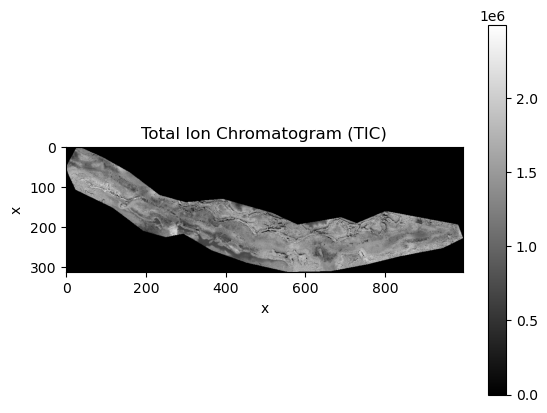

In [21]:
# get TIC array - TIC is returned as a 1D array
tic = reader.get_tic()
# convert the 1d array to 2d for visualization
tic2d = reader.reshape(tic)

fig, ax = plt.subplots()
im = ax.imshow(tic2d, cmap="gray")
ax.set(title="Total Ion Chromatogram (TIC)", xlabel="x", ylabel="x")
plt.colorbar(im)

In [22]:
# Good candidate for a pixel to align to
x_cond = reader.x_coordinates == 600
y_cond = reader.y_coordinates == 250

base_pixel_idx = np.where(x_cond & y_cond)[0][0]

## Preprocessing

### Find Peaks

In [ ]:
# get the summed spectrum for the entire dataset
x, y = reader.get_summed_spectrum(reader.pixels)
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(xlabel="m/z", ylabel="Intensity", title="Summed spectrum for the dataset")

# convert summed spectrum to an average spectrum
y_avg = y / reader.n_pixels
fig, ax = plt.subplots()
ax.plot(x, y_avg)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Average spectrum for the dataset")

In [ ]:
indices, _ = find_peaks(y_avg, height=np.mean(y_avg) + 25 * np.std(y_avg), distance=5)
px = x[indices]
py = y[indices]

### Align

In [8]:
def overlay_plot(ax, x, array, peak):
    """Generate overlay plot, showing each signal and the alignment peak(s)"""
    for i, y in enumerate(array):
        y = (y / y.max()) + (i * 0.2)
        ax.plot(x, y, lw=3)
    ax.axes.get_yaxis().set_visible(False)
    ax.set_xlabel("Index", fontsize=18)
    ax.set_xlim((x[0], x[-1]))
    ax.vlines(peak, *ax.get_ylim())

def find_nearest_index(x, peak):
    return (np.abs(x - peak)).argmin()
    
def plot_peak(ax, x, y, peak, window=100):
    peak_idx = find_nearest_index(x, peak)
    _x = x[peak_idx-window:peak_idx+window]
    _y = y[peak_idx-window:peak_idx+window]
    ax.plot(_x, _y)
    
    ax.axes.get_yaxis().set_visible(False)
    ax.set_xlim((_x[0], _x[-1]))
    ax.vlines(peak, *ax.get_ylim())

def zoom_plot(axs, x, array, aligned_array, peaks):
    for i, y in enumerate(array):
        for j, peak in enumerate(peaks):
            plot_peak(axs[0, j], x, y, peak)
            
    for i, y in enumerate(aligned_array):
        for j, peak in enumerate(peaks):
            plot_peak(axs[1, j], x, y, peak)

In [9]:
aligner.run()
aligned_array, shifts_out = aligner.apply(return_shifts=True)

# display before and after shifting
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
overlay_plot(ax[0], x, spectrum.reshape(1, len(spectrum)), peaks)
overlay_plot(ax[1], x, aligned_array, peaks)

# zoom-in on each peak
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 10))
zoom_plot(ax, x, spectrum.reshape(1, len(spectrum)), aligned_array, peaks)

NameError: name 'aligner' is not defined

### Normalization

In [10]:
def calculate_normalizations_optimized(spectrum: np.ndarray) -> np.ndarray:
    """Calculate various normalizations, optimized version.

    This function expects a float32 spectrum.
    """
    # Filter positive values once and reuse
    positive_spectrum = spectrum[spectrum > 0]

    # Calculating quantiles once for all needed
    if positive_spectrum.size > 1:
        q95, q90, q10, q5 = np.nanquantile(positive_spectrum, [0.95, 0.9, 0.1, 0.05])
    else:
        q95, q90, q10, q5 = 0, 0, 0, 0

    # Using logical indexing with boolean arrays might be faster due to numba optimization
    condition_q95 = spectrum < q95
    condition_q5 = spectrum > q5

    return 1/np.sum(spectrum[condition_q5 & condition_q95])  # 5-95% TIC

### Write to file

In [11]:
THRESHOLD = 0.0

vec_size = 0
start_time = t.time()
for i, elem in enumerate(tic):
    mz_vals, intensities = reader[i]
    vec_size += np.count_nonzero(intensities > THRESHOLD)  # Dense format

    if i%1_000 == 0: # Print out
        print(np.round(i/len(tic)*100, 2), '% in', np.round(t.time()-start_time), 's', end='\r')
total_entries = len(tic) * len(reader[1][0])
nonzero_entries = vec_size
fraction_nonzero = nonzero_entries/total_entries*100
print("We only need " + str(fraction_nonzero) + " percent of our data.")

We only need 13.552266422167255 percent of our data.


In [19]:
# One iteration of loop test-cell
from msalign import Aligner

base_align = reader[base_pixel_idx][0]
peaks = [728.6, 886.5, 904.6, 918.7] # Peaks that are present throughout the sample

start_time = t.time()
mz_vals, intensities = reader[1973]
intensities = intensities.astype('float32')
spectrum = intensities.reshape(1, len(intensities))

# Align
# instantiate aligner object
aligner = Aligner(
    base_align, 
    spectrum, 
    peaks, 
    weights=None,
    return_shifts=True,
    align_by_index=True,
    only_shift=True,
    method="pchip",
)
aligner.run()
aligned_array, shifts_out = aligner.apply(return_shifts=True)
aligned_array = aligned_array.ravel()  # flatten to 1D after apply()
        
# Normalize
sample = aligned_array[aligned_array > THRESHOLD]
norm_factor = calculate_normalizations_optimized(aligned_array)
sample = aligned_array * norm_factor

finish_time = t.time()
time_elapsed = finish_time - start_time

print("Time for one loop: " + str(time_elapsed))
print("Total time: " + str(time_elapsed*len(tic)/60/60) + " hours.")
print(sample.min(), sample.max(), sample.mean())
# Check how much precision you lose
print(np.max(np.abs(sample - sample.astype('float16'))))

Time for one loop: 0.05736827850341797
Total time: 1.7475493126445345 hours.
0.0 0.013873547 8.2476245e-06
3.773719e-06


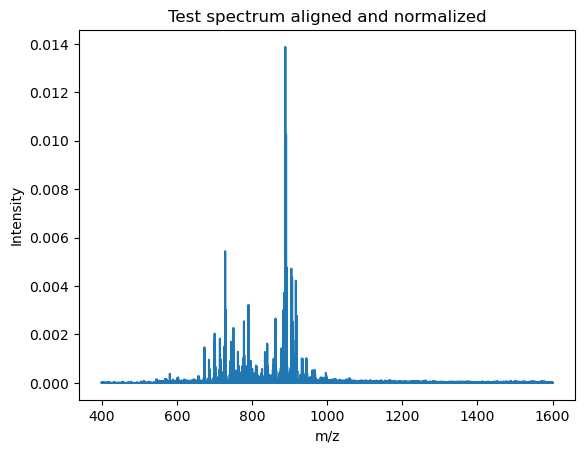

In [20]:
fig, ax = plt.subplots()
ax.plot(base_align, sample)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Test spectrum aligned and normalized")

In [26]:
# Zarr

from msalign import msalign
from msalign import Aligner
import zarr
import numcodecs
import numpy as np

base_align = reader[base_pixel_idx][0]
peaks = [728.6, 886.5, 904.6, 918.7]

compressor = numcodecs.Blosc(cname="lz4", clevel=5, shuffle=numcodecs.Blosc.SHUFFLE)

store = zarr.open("spectra_sparse.zarr", mode="w")
store.create_dataset("mz_axis",  data=base_align)
store.create_dataset("indptr",   shape=(len(tic)+1,), dtype='int64')
data_ds = store.create_dataset(
    "data",    shape=(nonzero_entries,), dtype='float16',
    chunks=(100_000,), compressor=compressor
)
idx_ds = store.create_dataset(
    "indices", shape=(nonzero_entries,), dtype='int32',
    chunks=(100_000,), compressor=compressor
)

ptr = 0
store["indptr"][0] = 0
start_time = t.time()

for e, _ in enumerate(tic):
    mz_vals, intensities = reader[e]
    intensities = intensities.astype('float32')
    spectrum = intensities.reshape(1, len(intensities))

    aligner = Aligner(
        base_align,
        spectrum,
        peaks,
        weights=None,
        return_shifts=True,
        align_by_index=True,
        only_shift=True,
        method="pchip",
    )
    aligner.run()
    aligned_array, shifts_out = aligner.apply(return_shifts=True)
    aligned_array = aligned_array.ravel()

    norm_factor = calculate_normalizations_optimized(aligned_array)

    mask    = aligned_array > THRESHOLD
    nz_vals = np.log1p(aligned_array[mask] * norm_factor).astype('float16')
    nz_idx  = np.where(mask)[0].astype('int32')
    n       = len(nz_vals)

    data_ds[ptr:ptr+n] = nz_vals
    idx_ds[ptr:ptr+n]  = nz_idx

    ptr += n
    store["indptr"][e+1] = ptr

    if e % 1_000 == 0:
        print(np.round(e/len(tic)*100, 2), '% in', np.round(t.time()-start_time), 's', end='\r')

print(f"\nStored {ptr:,} non-zeros")

50.15 % in 4579.0 s

C:\Users\WS2\AppData\Local\Temp\ipykernel_285688\2020726118.py:19: RuntimeWarning: divide by zero encountered in divide
  return 1/np.sum(spectrum[condition_q5 & condition_q95])  # 5-95% TIC


99.4 % in 9062.0 ss
Stored 3,799,866,669 non-zeros


In [27]:
# # HDF5

# from msalign import msalign
# from msalign import Aligner
# import h5py

# base_align = reader[base_pixel_idx][0] # Pick a representative pixel (one that's actually in the tissue)
# peaks = [728.6, 886.5, 904.6, 918.7] # Peaks that are present throughout the sample

# with h5py.File("spectra_sparse.h5", "w") as f:
#     # Store CSR components as resizable datasets
#     f.create_dataset("mz_axis", data=base_align)
#     f.create_dataset("indptr",  shape=(len(tic)+1,), dtype='int64')
    
#     # Pre-allocate with estimated size — use your real vec_size if known
#     data_ds = f.create_dataset(
#         "data", shape=(nonzero_entries,), dtype='float16', chunks=(100_000,), compression="gzip"
#     )
#     idx_ds = f.create_dataset(
#         "indices", shape=(nonzero_entries,), dtype='int32', chunks=(100_000,), compression="gzip"
#     )
    
#     ptr = 0
#     f["indptr"][0] = 0

#     start_time = t.time()
#     for e, _ in enumerate(tic):
#         mz_vals, intensities = reader[e]
#         intensities = intensities.astype('float32')
#         spectrum = intensities.reshape(1, len(intensities))
        
#         # Align
#         # instantiate aligner object
#         aligner = Aligner(
#             base_align, 
#             spectrum, 
#             peaks, 
#             weights=None,
#             return_shifts=True,
#             align_by_index=True,
#             only_shift=True,
#             method="pchip",
#         )
#         aligner.run()
#         aligned_array, shifts_out = aligner.apply(return_shifts=True)
#         aligned_array = aligned_array.ravel()  # flatten to 1D after apply()
        
#         # Normalize
#         norm_factor = calculate_normalizations_optimized(aligned_array)
        
#         # Sparse mask
#         mask = aligned_array > THRESHOLD
#         nz_vals = np.log1p(aligned_array[mask] * norm_factor).astype('float16')
#         nz_idx  = np.where(mask)[0].astype('int32')
#         n = len(nz_vals)
        
#         # Extend resizable datasets
#         # data_ds.resize(ptr + n, axis=0)
#         # idx_ds.resize(ptr + n, axis=0)
#         data_ds[ptr:ptr+n] = nz_vals
#         idx_ds[ptr:ptr+n]  = nz_idx
        
#         ptr += n
#         f["indptr"][e+1] = ptr
        
#         if e % 1_000 == 0:
#             print(np.round(e/len(tic)*100, 2), '% in', np.round(t.time()-start_time), 's', end='\r')

# print(f"\nStored {ptr:,} non-zeros")

### Low-Rank Matrix Factorization (Truncated-SVD)

In [30]:
print(f"Sparse matrix RAM estimate: {store['data'].nbytes / 1e9:.2f} GB")
print(f"Matrix density: {len(store['data']) / (n_pixels * n_mz_bins):.2%}")

Sparse matrix RAM estimate: 7.60 GB
Matrix density: 13.55%


In [2]:
import zarr
import scipy.sparse as sp
import numpy as np
from scipy.sparse.linalg import LinearOperator
import time as time

store = zarr.open("spectra_sparse.zarr", mode="r")
n_pixels  = len(store["indptr"]) - 1
n_mz_bins = len(store["mz_axis"])
batch_size = 10_000  # Controls peak RAM usage, not total

call_count = [0]  # mutable so it can be updated inside the closure
start_time = time.time()

def load_batch(start, end):
    """Load a slice of rows from Zarr as a sparse matrix."""
    ptr_start = store["indptr"][start]
    ptr_end   = store["indptr"][end]
    data = np.nan_to_num(store["data"][ptr_start:ptr_end].astype('float32'), nan=0.0, posinf=0.0, neginf=0.0)
    return sp.csr_matrix(
        (data,
        store["indices"][ptr_start:ptr_end],
        store["indptr"][start:end+1] - store["indptr"][start]),
        shape = (end - start, n_mz_bins)
    )

def matvec(v):
    """Compute M @ v chunk-by-chunk (n_pixels, n_mz_bins) @ (n_mz_bins,) -> (n_pixels,)"""
    call_count[0] += 1
    elapsed = time.time() - start_time
    print(f"matvec call {call_count[0]} | {elapsed:.0f}s elapsed", end='\r')
    
    out = np.zeros(n_pixels, dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out[start:end] = batch @ v
    return out

def rmatvec(v):
    """Compute M.T @ v chunk-by-chunk (n_mz_bins, n_pixels) @ (n_pixels,) -> (n_mz_bins,)"""
    
    call_count[0] += 1
    elapsed = time.time() - start_time
    print(f"matvec call {call_count[0]} | {elapsed:.0f}s elapsed", end='\r')
    
    out = np.zeros(n_mz_bins, dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out += batch.T @ v[start:end]
    return out

def matmat(Q):
    """M @ Q where Q is a matrix (n_mz_bins, k) -> (n_pixels, k)"""
    call_count[0] += 1
    k = Q.shape[1]
    print(f"matmat call {call_count[0]} | k={k}", end='\r')
    out = np.zeros((n_pixels, k), dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out[start:end] = batch @ Q
        print(f"matmat {call_count[0]} | {end/n_pixels*100:.0f}%", end='\r')
    return out

def rmatmat(Q):
    """M.T @ Q where Q is a matrix (n_pixels, k) -> (n_mz_bins, k)"""
    call_count[0] += 1
    k = Q.shape[1]
    print(f"rmatmat call {call_count[0]} | k={k}", end='\r')
    out = np.zeros((n_mz_bins, k), dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out += batch.T @ Q[start:end]
        print(f"rmatmat {call_count[0]} | {end/n_pixels*100:.0f}%", end='\r')
    return out

M_operator = LinearOperator(
    shape=(n_pixels, n_mz_bins),
    matvec=matvec,
    rmatvec=rmatvec,
    matmat=matmat,
    rmatmat=rmatmat,
    dtype='float32'
)

In [ ]:
from sklearn.utils.extmath import _randomized_svd

# Run randomized SVD — n_iter controls accuracy vs speed tradeoff
U, S, Vt = _randomized_svd(
    M_operator,
    n_components=100,
    n_iter=1,        # Higher = more accurate, more passes through data
    random_state=42
)

print(f"U:  {U.shape}")   # (n_pixels, 100)
print(f"S:  {S.shape}")   # (100,)
print(f"Vt: {Vt.shape}")  # (100, n_mz_bins)

# X_reduced is your PCA-equivalent coordinates per pixel
X_reduced = U * S  # (n_pixels, 100)

np.save("X_reduced.npy", X_reduced)
np.save("Vt.npy", Vt)
np.save("S.npy", S)
np.save("U.npy", U)

### Verifying SVD

In [6]:
# 1. Singular values should be monotonically decreasing
print("Singular values (first 10):", S[:10])
print("Monotonically decreasing:", np.all(np.diff(S) <= 0))

Singular values (first 10): [12.134757   9.229674   5.2138042  3.0844262  1.8132671  1.4525242
  1.2258301  1.1735317  1.1578665  1.0531706]
Monotonically decreasing: True


In [7]:
# 2. Explained variance — how much of the signal is captured
explained = (S**2) / (S**2).sum()
cumulative = np.cumsum(explained)
print(f"Top 10 components explain: {cumulative[9]:.1%}")
print(f"Top 50 components explain: {cumulative[49]:.1%}")
print(f"Top 100 components explain: {cumulative[99]:.1%}")

Top 10 components explain: 97.4%
Top 50 components explain: 99.7%
Top 100 components explain: 100.0%


In [13]:
# 3. U should be orthonormal — U.T @ U ≈ Identity
UtU = U[:, :10].T @ U[:, :10]
print("U orthonormality error:", np.abs(UtU - np.eye(10)).max())

U orthonormality error: 1.0728836059570312e-06


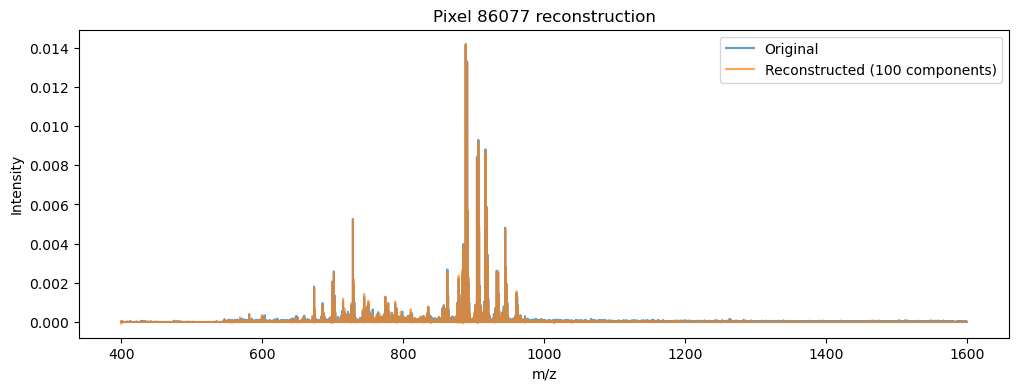

In [24]:
# 4. Reconstruct a single pixel and compare to original

reconstructed = (U[base_pixel_idx, :] * S) @ Vt  # shape (n_mz_bins,)
batch = load_batch(base_pixel_idx, base_pixel_idx + 1).toarray().ravel() # Load the original

import matplotlib.pyplot as plt
mz_axis = store["mz_axis"][:]
plt.figure(figsize=(12, 4))
plt.plot(mz_axis, batch, label='Original', alpha=0.7)
plt.plot(mz_axis, reconstructed, label='Reconstructed (100 components)', alpha=0.7)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.legend()
plt.title(f"Pixel {base_pixel_idx} reconstruction")
plt.show()

In [27]:
Vt.shape

(100, 255681)

Top m/z values for component 0:
  m/z 888.6216: loading 0.1499
  m/z 888.6262: loading 0.1482
  m/z 888.6402: loading 0.1444
  m/z 888.6309: loading 0.1440
  m/z 888.6449: loading 0.1436
  m/z 888.6356: loading 0.1426
  m/z 888.6169: loading 0.1425
  m/z 890.6374: loading 0.1394
  m/z 890.6421: loading 0.1368
  m/z 890.6327: loading 0.1350
  m/z 888.6496: loading 0.1333
  m/z 890.6467: loading 0.1317
  m/z 890.6514: loading 0.1274
  m/z 890.6561: loading 0.1233
  m/z 888.6123: loading 0.1228
  m/z 890.6281: loading 0.1208
  m/z 890.6608: loading 0.1159
  m/z 888.6542: loading 0.1107
  m/z 906.6296: loading 0.1048
  m/z 906.6343: loading 0.1018


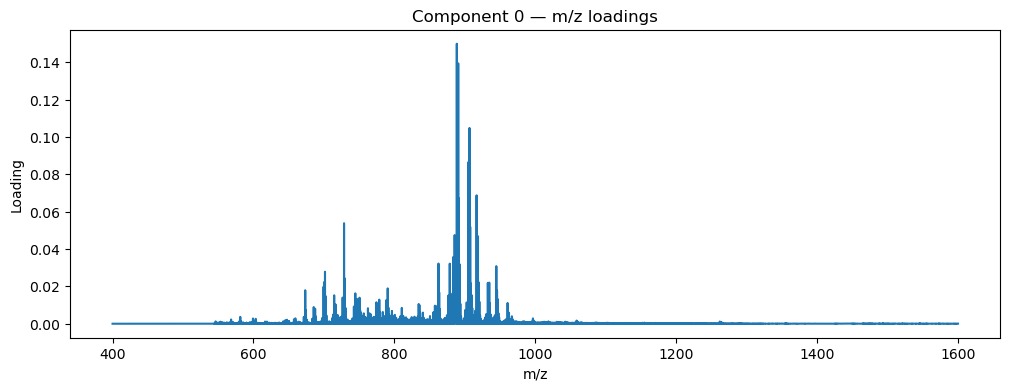

In [28]:
mz_axis = store["mz_axis"][:]  # shape (n_mz_bins,)

# For a given component, find the m/z values with highest loading
component_idx = 0  # first (most important) component
loadings = Vt[component_idx, :]  # shape (n_mz_bins,)

# Top 20 m/z values driving this component
top_idx = np.argsort(np.abs(loadings))[::-1][:20]
top_mz  = mz_axis[top_idx]
top_loadings = loadings[top_idx]

print("Top m/z values for component 0:")
for mz, loading in zip(top_mz, top_loadings):
    print(f"  m/z {mz:.4f}: loading {loading:.4f}")

# Plot the full loading spectrum for a component
plt.figure(figsize=(12, 4))
plt.plot(mz_axis, loadings)
plt.xlabel("m/z")
plt.ylabel("Loading")
plt.title(f"Component {component_idx} — m/z loadings")
plt.show()

## PCA

In [ ]:
import sklearn
from sklearn.preprocessing import StandardScaler
downsampled_scaled = StandardScaler().fit_transform(downsampled)

In [ ]:
# tic_norm = y/tic[0]
fig, ax = plt.subplots()
ax.plot(bins[:-1], downsampled[0])
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Spectrum for pixel 0")

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, svd_solver="randomized")
downsampled_pca = pca.fit_transform(downsampled_scaled)

In [ ]:
# Get the eigenvalues (explained variance) or explained variance ratio
PC_values = np.arange(pca.n_components_) + 1
explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_ * 100

# Create the scree plot
plt.figure(figsize=(10, 6))
plt.bar(PC_values, explained_variance_ratio, color='skyblue') # Or use explained_variance_ratio
plt.title('Scree Plot')
plt.xlabel('Number of Components')
#plt.ylabel('Eigenvalues')
plt.ylabel('Proportion of Variance Explained (%)')
#plt.axhline(y=1, color='r', linestyle='-') # Optional: Kaiser rule cutoff line [Medium](https://sanchitamangale12.medium.com/scree-plot-733ed72c8608)
plt.grid(True)
plt.show()


In [ ]:
explained_variance

## k-Means Clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0, init="k-means++", n_init="auto").fit(downsampled_pca)

In [ ]:
y_kmeans = kmeans.predict(downsampled_pca)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

# Plot the data points, colored by cluster
plt.scatter(downsampled_pca[:, 0], downsampled_pca[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data points')

# Plot the cluster centers (centroids) as large 'X' markers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')

plt.title('K-Means Clustering Visualization (2D)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


## UMAP

In [ ]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    n_components=2
)

embedding = umap_model.fit_transform(downsampled_pca)

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(embedding[:,0], embedding[:,1], s=3)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## Other Stuff

In [ ]:
def spectrum_to_binned_vector:
    

mz_min = 300
mz_max = 2000
bin_width = 0.1   # 0.1 Da is common, but depends on instrument

bins = np.arange(mz_min, mz_max + bin_width, bin_width)

binned_spectra = []
spectrum_ids = []

for spec in spectra_data:
    vec = spectrum_to_binned_vector(
        spec["mzs"],
        spec["intensities"],
        bins
    )
    binned_spectra.append(vec)

X = np.vstack(binned_spectra)

from scipy.sparse import csr_matrix

X_sparse = csr_matrix(X)

In [ ]:
# get the summed spectrum for the entire dataset
x, y = reader.get_summed_spectrum(reader.pixels)
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(xlabel="m/z", ylabel="Intensity", title="Summed spectrum for the dataset")

# convert summed spectrum to an average spectrum
y_avg = y / reader.n_pixels
fig, ax = plt.subplots()
ax.plot(x, y_avg)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Average spectrum for the dataset")

In [ ]:
# you can also obtain normalizations for each pixel
# the data is returned as dict mapping of 'normalization name' to array of scaling factors
# the values are to be used as multipliers of the spectra
norms = reader.get_normalizations()
# get the names of the available normalizations
list(norms.keys())

In [ ]:
norms["TIC"]

In [ ]:
# you can also visualise the normalization factors
scales2d = reader.reshape(norms["TIC"])
fig, ax = plt.subplots()
im = ax.imshow(scales2d, cmap="viridis")
ax.set(title="TIC normalization factors", xlabel="x", ylabel="y")

In [ ]:
# you can use the normalization values when extracting the summed spectrum
scales = norms["TIC"]
x, y_norm = reader.get_summed_spectrum(reader.pixels, scales=scales)
fig, ax = plt.subplots()
ax.plot(x, y_norm)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Normalized summed spectrum for the dataset")

In [ ]:
# get random spectrum from the dataset
x, y = reader.get_spectrum(0)

fig, ax = plt.subplots()
ax.plot(x, y)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Spectrum for pixel 0")

In [ ]:
# get random spectrum from the dataset
x, y = reader.get_spectrum(0)
y = y * scales[0]

fig, ax = plt.subplots()
ax.plot(x, y)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Normalized spectrum for pixel 0")

In [ ]:
# find peaks in the spectrum
indices, _ = find_peaks(y, height=np.mean(y) + 3 * np.std(y), distance=5)
px = x[indices]
py = y[indices]

fig, ax = plt.subplots()
ax.plot(x, y)
ax.plot(px, py, "x")
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Spectrum for pixel 0 with peaks")

In [ ]:
# extract ion image for a given m/z value with a tolerance
# let's get the highest peak in the spectrum
mz = px[np.argmax(py)]

# you can extract images one-by-one which can be fairly slow, or in batches
# here, we just get a single image with integration window of 5ppm but you could also specify in Da
image_for_mz = reader.get_ion_image(mz, ppm=5)

fig, ax = plt.subplots()
im = ax.imshow(image_for_mz, cmap="gray")
ax.set(title=f"Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)

In [ ]:
# you can also normalize the image using the normalization factors
# however to do that you need to provide the normalization factors as a 2D array
scales2d = reader.reshape(scales)
image_for_mz_norm = image_for_mz * scales2d
fig, ax = plt.subplots()
im = ax.imshow(image_for_mz_norm, cmap="gray")
ax.set(title=f"Normalized Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)

In [ ]:
# or you can extract images in batches which is much faster
images_for_mzs = reader.get_ion_images(px, ppm=5)

In [ ]:
# let's plot a couple of images, maybe random 20 in a grid of 4x5
n_images = 20
random_indices = np.random.choice(len(px), size=n_images, replace=False)
fig, axs = plt.subplots(4, 5, figsize=(15, 10))
for i, ax in enumerate(axs.flat):
    if i < n_images:
        im = ax.imshow(images_for_mzs[random_indices[i]], cmap="gray")
        ax.set(title=f"m/z = {px[random_indices[i]]:.2f}", xlabel="x", ylabel="y")
        plt.colorbar(im, ax=ax)
    else:
        ax.axis("off")